In [17]:
%pip install unidecode
%pip install fuzzywuzzy python-Levenshtein

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import unidecode
from fuzzywuzzy import fuzz, process
from geopy.geocoders import Nominatim
import time
import pickle

In [2]:
# Load the Volontaire dataset
challenge_dataset_path = ('..\docs\data\processed\Challenge dataset.xlsx')
df_volontaire = pd.read_excel(challenge_dataset_path, sheet_name='Volontaire')

# Load the Cameroon map shapefile
cameroon_map = gpd.read_file('..\docs\data\processed\CM_Cities.shp')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Larry\AppData\Local\Temp\ipykernel_17600\3628671821.py:2: SyntaxWarning: invalid escape sequence '\d'
  challenge_dataset_path = ('..\docs\data\processed\Challenge dataset.xlsx')
C:\Users\Larry\AppData\Local\Temp\ipykernel_17600\3628671821.py:6: SyntaxWarning: invalid escape sequence '\d'
  cameroon_map = gpd.read_file('..\docs\data\processed\CM_Cities.shp')


In [3]:
# Print the column names
print("Column names in Volontaire dataset:", df_volontaire.columns.tolist())

Column names in Volontaire dataset: ['ID', 'Age', 'Horodateur', "Niveau_d'etude", 'Genre_', 'Taille_', 'Poids', 'Situation_Matrimoniale_(SM)', 'Profession_', 'Arrondissement_de_résidence_', 'Quartier_de_Résidence_', 'Nationalité_', 'Religion_', 'A-t-il_(elle)_déjà_donné_le_sang_', 'Si_oui_preciser_la_date_du_dernier_don._', 'Taux_d’hémoglobine_', 'ÉLIGIBILITÉ_AU_DON.', 'Raison_indisponibilité__[Est_sous_anti-biothérapie__]', 'Raison_indisponibilité__[Taux_d’hémoglobine_bas_]', 'Raison_indisponibilité__[date_de_dernier_Don_<_3_mois_]', 'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]', 'Date_de_dernières_règles_(DDR)__', 'Raison_de_l’indisponibilité_de_la_femme_[La_DDR_est_mauvais_si_<14_jour_avant_le_don]', 'Raison_de_l’indisponibilité_de_la_femme_[Allaitement_]', 'Raison_de_l’indisponibilité_de_la_femme_[A_accoucher_ces_6_derniers_mois__]', 'Raison_de_l’indisponibilité_de_la_femme_[Interruption_de_grossesse__ces_06_derniers_mois]', 'Raison_de_l’indisponibilité_de_la_femme_

In [4]:
import geopandas as gpd

# Load the Cameroon map shapefile
cameroon_map = gpd.read_file('..\docs\data\processed\CM_Cities.shp')

# Print the column names
print(cameroon_map.columns)

Index(['geometry'], dtype='object')


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Larry\AppData\Local\Temp\ipykernel_17600\1948405284.py:4: SyntaxWarning: invalid escape sequence '\d'
  cameroon_map = gpd.read_file('..\docs\data\processed\CM_Cities.shp')


In [5]:
# Standardize Arrondissement names function
def standardize_name(name):
    if pd.notna(name):
        return unidecode.unidecode(name.lower().strip())
    return name

# Standardize Arrondissement names in df_volontaire
df_volontaire['Arrondissement'] = df_volontaire['Arrondissement_de_résidence_'].apply(standardize_name)

# Print unique Arrondissement names from df_volontaire
map_arrondissements = df_volontaire['Arrondissement'].unique()
print("Unique Arrondissement names:", map_arrondissements)

Unique Arrondissement names: ['douala 3' 'r a s' 'douala 1' 'douala 5' 'douala (non precise )'
 'non precise' 'douala 2' 'douala 4' 'yaounde' 'meiganga' 'edea' 'ras'
 'oyack' 'manjo' 'douala 6' 'pas precise' 'tiko' 'bafoussam' 'boko'
 'kribi' 'west' 'njombe' 'nkouabang' 'ngodi bakoko' 'buea' 'dschang'
 'bomono ba mbegue' 'douala' 'dcankongmondo' 'limbe' 'deido'
 'sud ouest tombel' 'pas mentionne']


In [6]:
# Fuzzy match Arrondissements with improved matching logic
def fuzzy_match_arrondissement(arrondissement):
    match = process.extractOne(arrondissement, map_arrondissements, scorer=fuzz.token_sort_ratio)
    return match[0] if match and match[1] >= 80 else arrondissement  # Adjust threshold as needed

df_volontaire['Arrondissement_Matched'] = df_volontaire['Arrondissement'].apply(fuzzy_match_arrondissement)

In [7]:
# Keep only valid Arrondissements that are present in the map
df_volontaire_cleaned = df_volontaire[df_volontaire['Arrondissement_Matched'].isin(map_arrondissements)]

In [8]:
# Display cleaned DataFrame
print("Cleaned DataFrame:")
print(df_volontaire_cleaned[['Arrondissement_Matched', 'Quartier_de_Résidence_']])

Cleaned DataFrame:
     Arrondissement_Matched Quartier_de_Résidence_
0                  douala 3                  Yassa
1                     r a s                  R A S
2                  douala 1               NEW BELL
3                  douala 5           Ange raphael
4     douala (non precise )                  Beedi
...                     ...                    ...
1841               douala 3               Ndogbong
1842  douala (non precise )                   Pk14
1843  douala (non precise )      Cite des palmiers
1844  douala (non precise )          Douala douala
1845               douala 3             PK16 NSAPE

[1846 rows x 2 columns]


In [9]:
# Initialize the Nominatim geocoder
geolocator = Nominatim(user_agent="myGeocoder")

# List of Arrondissements to geocode
arrondissements = df_volontaire_cleaned['Arrondissement_Matched'].unique()
arrondissement_coords = {}

# Geocode each arrondissement
for town in arrondissements:
    try:
        location = geolocator.geocode(town + ', Cameroon', timeout=10)
        if location:
            arrondissement_coords[town] = (location.latitude, location.longitude)
        time.sleep(1)
    except Exception as e:
        print(f"Geocoding error for {town}: {e}")
        time.sleep(5)

In [10]:
# Create a new DataFrame to hold coordinates
df_volontaire_cleaned['Coordinates'] = df_volontaire_cleaned['Arrondissement_Matched'].map(arrondissement_coords)

# Split the Coordinates into separate latitude and longitude columns
df_volontaire_cleaned[['Latitude', 'Longitude']] = pd.DataFrame(df_volontaire_cleaned['Coordinates'].tolist(), index=df_volontaire_cleaned.index)

# Drop rows where coordinates are not available
df_volontaire_cleaned.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Display updated DataFrame
print("\nVolontaire Dataset with Coordinates:")
print(df_volontaire_cleaned[['Arrondissement_Matched', 'Latitude', 'Longitude']])


Volontaire Dataset with Coordinates:
     Arrondissement_Matched  Latitude  Longitude
0                  douala 3  4.028425   9.781926
1                     r a s  4.010561   9.748672
2                  douala 1  3.861247   9.623577
3                  douala 5  4.135387   9.803438
8                  douala 2  4.016033   9.713089
...                     ...       ...        ...
1838               douala 4  4.078437   9.646548
1839               douala 3  4.028425   9.781926
1840                yaounde  3.868987  11.521334
1841               douala 3  4.028425   9.781926
1845               douala 3  4.028425   9.781926

[866 rows x 3 columns]


In [11]:
# Count donors by arrondissement
donor_counts = df_volontaire_cleaned.groupby('Arrondissement_Matched').size().reset_index(name='Donor Count')

C:\Users\Larry\AppData\Local\Temp\ipykernel_17600\1393237838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=donor_counts, x='Arrondissement_Matched', y='Donor Count', palette='viridis')


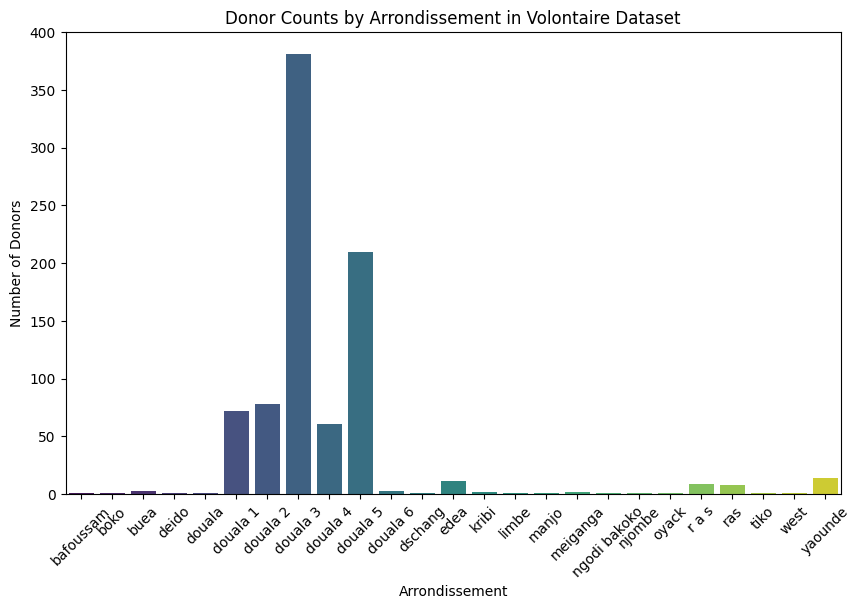

In [12]:
# Plotting the donor counts by arrondissement
plt.figure(figsize=(10, 6))
sns.barplot(data=donor_counts, x='Arrondissement_Matched', y='Donor Count', palette='viridis')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.title('Donor Counts by Arrondissement in Volontaire Dataset')  # Title of the plot
plt.xlabel('Arrondissement')  # x-axis label
plt.ylabel('Number of Donors')  # y-axis label
plt.show()  # Display the plot

In [13]:
# Create a GeoDataFrame for donors based on their coordinates
donors_geo = gpd.GeoDataFrame(df_volontaire_cleaned, geometry=gpd.points_from_xy(df_volontaire_cleaned.Longitude, df_volontaire_cleaned.Latitude))

# Set the coordinate reference system to match the Cameroon map
donors_geo.crs = cameroon_map.crs

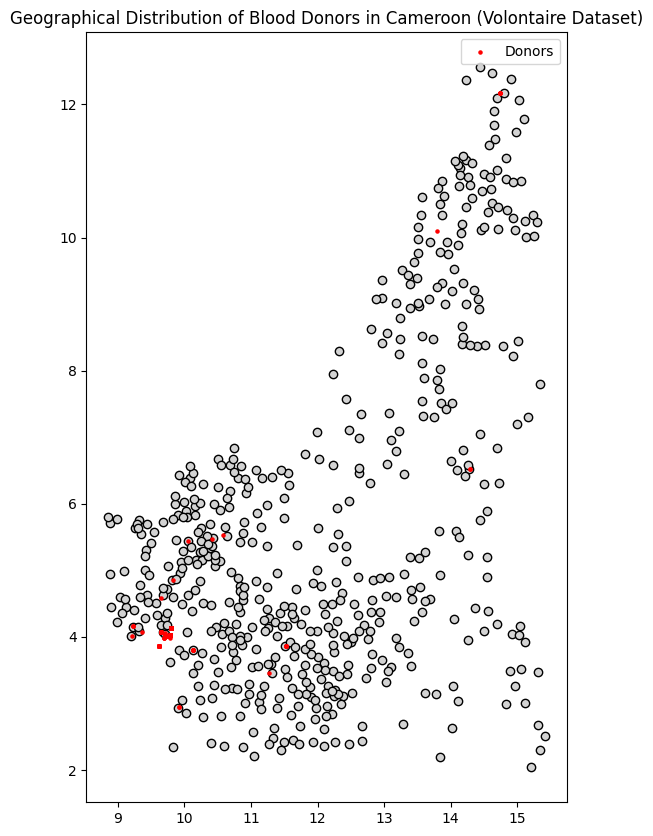

In [14]:
# Plotting the map with donor locations
fig, ax = plt.subplots(figsize=(12, 10))  # Create a figure and axis
cameroon_map.plot(ax=ax, color='lightgrey', edgecolor='black')  # Plot the Cameroon map
donors_geo.plot(ax=ax, marker='o', color='red', markersize=5, label='Donors')  # Plot donor locations
plt.title('Geographical Distribution of Blood Donors in Cameroon (Volontaire Dataset)')  # Title of the map
plt.legend()  # Show legend
plt.show()  # Display the map

In [15]:
# Create an interactive map using Folium
m = folium.Map(location=[3.848, 11.5021], zoom_start=6)

# Add donor locations to the map as circle markers
for idx, row in df_volontaire_cleaned.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=f"Arrondissement: {row['Arrondissement_Matched']}<br>Quartier: {row['Quartier_de_Résidence_']}"
    ).add_to(m)

# Display the map
m

In [16]:
# Test sample locations
sample_locations = ['D o u a l a', 'Yaounde', 'Edea', 'Non précisé']
for location in sample_locations:
    standardized_location = unidecode.unidecode(location.lower().strip())
    if standardized_location in map_arrondissements:
        print(f"{location} is found on the map.")
    else:
        print(f"{location} is NOT found on the map.")

D o u a l a is NOT found on the map.
Yaounde is found on the map.
Edea is found on the map.
Non précisé is found on the map.
